**SeriousDlqin2yrs**: Whether the person experienced serious delinquency (90+ days late) within the next 2 years. 1 = Yes, 0 = No. This is the target variable.

**RevolvingUtilizationOfUnsecuredLines**: The percentage of available unsecured revolving credit currently being used. Roughly: credit used / total credit limit. Higher values generally indicate greater credit utilization.

**age**: Age of the borrower in years.

**NumberOfTime30-59DaysPastDueNotWorse**: Number of times the borrower was 30–59 days past due on a payment, without progressing to worse delinquency.

**DebtRatio**: Ratio of the borrower's monthly debt payments to monthly gross income. Higher values indicate a larger portion of income going toward debt.

**MonthlyIncome**: Borrower's monthly income.

**NumberOfOpenCreditLinesAndLoans**: Number of currently open credit accounts, including credit cards, loans, etc.

**NumberOfTimes90DaysLate**: Number of times the borrower was 90 or more days late on a payment.

**NumberRealEstateLoansOrLines**: Number of real-estate-related loans or credit lines, such as mortgages and home-equity lines of credit.

**NumberOfTime60-89DaysPastDueNotWorse**: Number of times the borrower was 60–89 days past due on a payment, without progressing to worse delinquency.

**NumberOfDependents**: Number of dependents financially supported by the borrower, excluding the borrower themselves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\bhavy\\Downloads\\cs-training.csv")

df.sample(3)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
114415,114416,0,0.041472,69,0,72.000000,NaN,9,0,0,0,0.0
53690,53691,0,0.016135,62,0,0.393491,8050.0,14,0,2,0,0.0
94088,94089,0,0.602350,57,0,2737.000000,NaN,8,0,1,0,0.0


In [3]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [4]:
df.duplicated().sum()

0

In [5]:
data = df.copy()

In [6]:
data.drop(['Unnamed: 0'],axis=1,inplace=True)

In [7]:
data = data[['age','RevolvingUtilizationOfUnsecuredLines',
      'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse',
      'NumberOfTimes90DaysLate','DebtRatio', 'MonthlyIncome',
      'NumberOfOpenCreditLinesAndLoans','NumberRealEstateLoansOrLines','NumberOfDependents','SeriousDlqin2yrs']]

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 3   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 4   NumberOfTimes90DaysLate               150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfDependents                    146076 non-null  float64
 10  SeriousDlqin2yrs                      150000 non-null  int64  
dtype

**NaNs in NumberOfDependents generally means that the person has 0 dependents. Hence, we'll fill the NaN values with 0**

In [9]:
data['NumberOfDependents'] = data['NumberOfDependents'].fillna(0)

**We'll now check missing values in DebtRatio and MonthlyIncome**

In [10]:
data[data['DebtRatio']>1][['DebtRatio','MonthlyIncome']]

,DebtRatio,MonthlyIncome
6,5710.000000,NaN
8,46.000000,NaN
14,477.000000,0.0
16,2058.000000,NaN
25,1.595253,4676.0
...,...,...
149976,60.000000,NaN
149977,349.000000,NaN
149984,25.000000,NaN
149992,4132.000000,NaN


**DebtRatio can be greater than 1, but we see unusual values here. It looks like monthly income values have been written inside DebtRatio**

In [11]:
data[(data['MonthlyIncome'].isna()) & (data['DebtRatio']<500)][['DebtRatio','MonthlyIncome']]

,DebtRatio,MonthlyIncome
8,46.0,NaN
41,75.0,NaN
52,0.0,NaN
96,10.0,NaN
100,15.0,NaN
...,...,...
149960,353.0,NaN
149965,98.0,NaN
149976,60.0,NaN
149977,349.0,NaN


**We will drop these values because a MonthlyIncome below 500 is very low**

In [12]:
mask = (data['MonthlyIncome'].isna()) & (data['DebtRatio'] < 500)

data = data.drop(data[mask].index)

**Now we'll see for values where MonthlyIncome is greater than or equal to 500**

In [13]:
data[(data['MonthlyIncome'].isna()) & (data['DebtRatio'] >= 500)][['DebtRatio','MonthlyIncome']]

,DebtRatio,MonthlyIncome
6,5710.0,NaN
16,2058.0,NaN
32,977.0,NaN
58,2477.0,NaN
62,1720.0,NaN
...,...,...
149963,883.0,NaN
149967,517.0,NaN
149975,2716.0,NaN
149992,4132.0,NaN


**For this data, we will enter debt ratio values to monthly income column and change debt ratio values to NaN**

In [14]:
mask = (data['MonthlyIncome'].isna()) & (data['DebtRatio'] >= 500)

data.loc[mask, 'MonthlyIncome'] = data.loc[mask, 'DebtRatio']
data.loc[mask, 'DebtRatio'] = float('nan')

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139578 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   139578 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  139578 non-null  float64
 2   NumberOfTime30-59DaysPastDueNotWorse  139578 non-null  int64  
 3   NumberOfTime60-89DaysPastDueNotWorse  139578 non-null  int64  
 4   NumberOfTimes90DaysLate               139578 non-null  int64  
 5   DebtRatio                             120269 non-null  float64
 6   MonthlyIncome                         139578 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       139578 non-null  int64  
 8   NumberRealEstateLoansOrLines          139578 non-null  int64  
 9   NumberOfDependents                    139578 non-null  float64
 10  SeriousDlqin2yrs                      139578 non-null  int64  
dtypes: fl

In [16]:
data['DebtRatio'].mean()

26.598777445397225

In [17]:
data[data['DebtRatio']>1]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
14,76,0.019657,0,0,0,477.000000,0.0,6,1,0.0,0
25,50,0.392248,0,0,0,1.595253,4676.0,14,3,1.0,1
44,68,0.368876,0,0,0,1687.500000,1.0,31,1,0.0,0
50,73,0.818978,0,1,0,3095.000000,0.0,9,1,0.0,0
63,46,0.009789,0,0,0,1.051398,3326.0,6,2,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...
149841,54,0.009088,0,0,0,1.061506,11250.0,12,4,0.0,1
149882,77,0.062398,0,0,0,714.500000,1.0,3,0,0.0,0
149907,60,0.309121,0,0,0,1.124589,9125.0,11,4,0.0,0
149950,61,0.004827,0,0,0,1940.000000,0.0,10,1,0.0,0


In [18]:
data[(data['MonthlyIncome']==0) | (data['MonthlyIncome']==1)][['DebtRatio','MonthlyIncome']]

,DebtRatio,MonthlyIncome
14,477.0,0.0
44,1687.5,1.0
50,3095.0,0.0
73,3162.0,0.0
90,15466.0,0.0
...,...,...
149562,430.0,0.0
149646,1248.0,0.0
149673,4123.0,0.0
149882,714.5,1.0


**We see again that monthly income values are filled in DebtRatio here.**

**First we drop those rows from this data where income is less than 500 (ie, debt ratio value here is less than 500)**

In [19]:
mask = (data['MonthlyIncome'].isin([0, 1]) &(data['DebtRatio'] < 500))

data = data.drop(data[mask].index)

In [20]:
data[(data['MonthlyIncome']==0) | (data['MonthlyIncome']==1)][['DebtRatio','MonthlyIncome']]

,DebtRatio,MonthlyIncome
44,1687.5,1.0
50,3095.0,0.0
73,3162.0,0.0
90,15466.0,0.0
167,639.5,1.0
...,...,...
149462,1450.5,1.0
149646,1248.0,0.0
149673,4123.0,0.0
149882,714.5,1.0


**Now we'll change the value of DebtRatio to MonthlyIncome and make DebtRatio to NaN**

In [21]:
mask = data['MonthlyIncome'].isin([0, 1])

data.loc[mask, 'MonthlyIncome'] = data.loc[mask, 'DebtRatio']
data.loc[mask, 'DebtRatio'] = float('nan')

In [22]:
data['DebtRatio'].mean(), data['DebtRatio'].median()

(0.4172783578791748, 0.29118396550000003)

**Now the Ratio looks fine**

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138644 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   138644 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  138644 non-null  float64
 2   NumberOfTime30-59DaysPastDueNotWorse  138644 non-null  int64  
 3   NumberOfTime60-89DaysPastDueNotWorse  138644 non-null  int64  
 4   NumberOfTimes90DaysLate               138644 non-null  int64  
 5   DebtRatio                             118030 non-null  float64
 6   MonthlyIncome                         138644 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       138644 non-null  int64  
 8   NumberRealEstateLoansOrLines          138644 non-null  int64  
 9   NumberOfDependents                    138644 non-null  float64
 10  SeriousDlqin2yrs                      138644 non-null  int64  
dtypes: fl

**Now, we will fill the Na values of DebtRatio with median, but also create a column of DebtRatioMissing which will have 0 or 1 value**

In [24]:
data['DebtRatioMissing'] = data['DebtRatio'].isna().astype(int)

In [25]:
data['DebtRatio'] = data['DebtRatio'].fillna(data['DebtRatio'].median())

In [26]:
data.columns

Index(['age', 'RevolvingUtilizationOfUnsecuredLines',
       'NumberOfTime30-59DaysPastDueNotWorse',
       'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
       'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents',
       'SeriousDlqin2yrs', 'DebtRatioMissing'],
      dtype='object')

In [27]:
data = data[['age', 'RevolvingUtilizationOfUnsecuredLines',
       'NumberOfTime30-59DaysPastDueNotWorse',
       'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
       'DebtRatio','DebtRatioMissing','MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberRealEstateLoansOrLines', 'NumberOfDependents',
       'SeriousDlqin2yrs']]

In [28]:
data.sample(3)

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
144974,62,0.034105,0,0,0,0.294135,0,6666.0,10,1,0.0,0
110315,65,0.090826,0,0,0,0.291184,1,3788.0,7,2,0.0,0
27554,57,0.491031,1,0,0,0.577279,0,5615.0,18,1,2.0,0


In [29]:
data['age'].min()

0

In [30]:
data[(data['age']==0) & (data['age']<=18)]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
65695,0,1.0,1,0,0,0.436927,0,6000.0,6,2,2.0,0


In [31]:
data[(data['age']==0) | (data['age']>100)]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
19884,103,1.000000,0,0,0,0.000000,0,1600.0,3,0,0.0,0
25561,102,0.009866,0,0,0,0.002424,0,3300.0,3,0,0.0,0
40007,107,0.064748,0,0,0,0.291184,1,939.0,9,1,0.0,0
57967,103,0.001397,0,0,0,0.291184,1,1798.5,11,2,0.0,0
65695,0,1.000000,1,0,0,0.436927,0,6000.0,6,2,2.0,0
93813,101,0.025780,0,0,0,0.013797,0,1666.0,5,0,0.0,0
96450,102,0.109642,0,0,0,0.273844,0,3417.0,7,0,1.0,0
105790,109,0.109307,0,0,0,0.291184,1,2141.0,17,1,0.0,0
116129,101,0.002964,2,0,0,0.001387,0,2883.0,6,0,0.0,1


In [32]:
data = data[data['age'] != 0]

<Axes: xlabel='RevolvingUtilizationOfUnsecuredLines', ylabel='Density'>

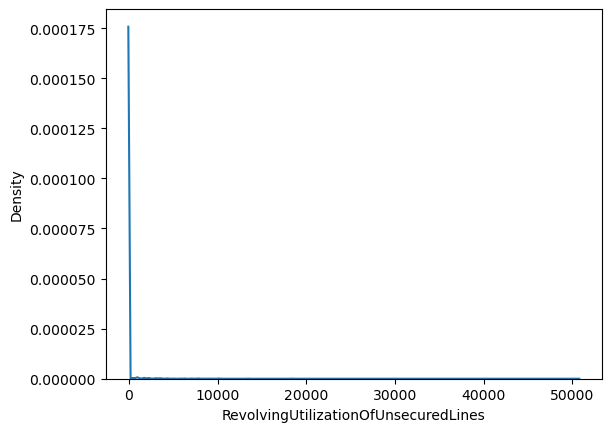

In [33]:
sns.kdeplot(data['RevolvingUtilizationOfUnsecuredLines'])

In [34]:
data[data['RevolvingUtilizationOfUnsecuredLines']>4]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
293,45,2340.000000,0,0,0,0.339333,0,8333.0,7,2,2.0,0
697,58,2066.000000,0,0,1,0.271121,0,6000.0,8,1,1.0,1
1991,44,1143.000000,2,0,0,0.547762,0,6500.0,13,4,2.0,1
2331,59,6324.000000,0,0,0,0.136673,0,11318.0,4,1,1.0,0
4278,33,1982.000000,0,0,0,0.144982,0,8000.0,4,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
148828,53,73.846154,2,0,8,0.513355,0,7000.0,5,2,4.0,1
149102,43,6109.000000,0,0,0,0.229902,0,12500.0,9,2,0.0,0
149160,38,22000.000000,0,0,0,1.080020,0,3973.0,7,2,3.0,0
149245,52,771.000000,0,0,0,0.832021,0,8000.0,13,3,0.0,0


**These values entered are errors, and there is no considerable method to recover them, hence will be dropped**

In [35]:
data = data[data['RevolvingUtilizationOfUnsecuredLines'] <= 4]

<Axes: xlabel='NumberOfTimes90DaysLate', ylabel='count'>

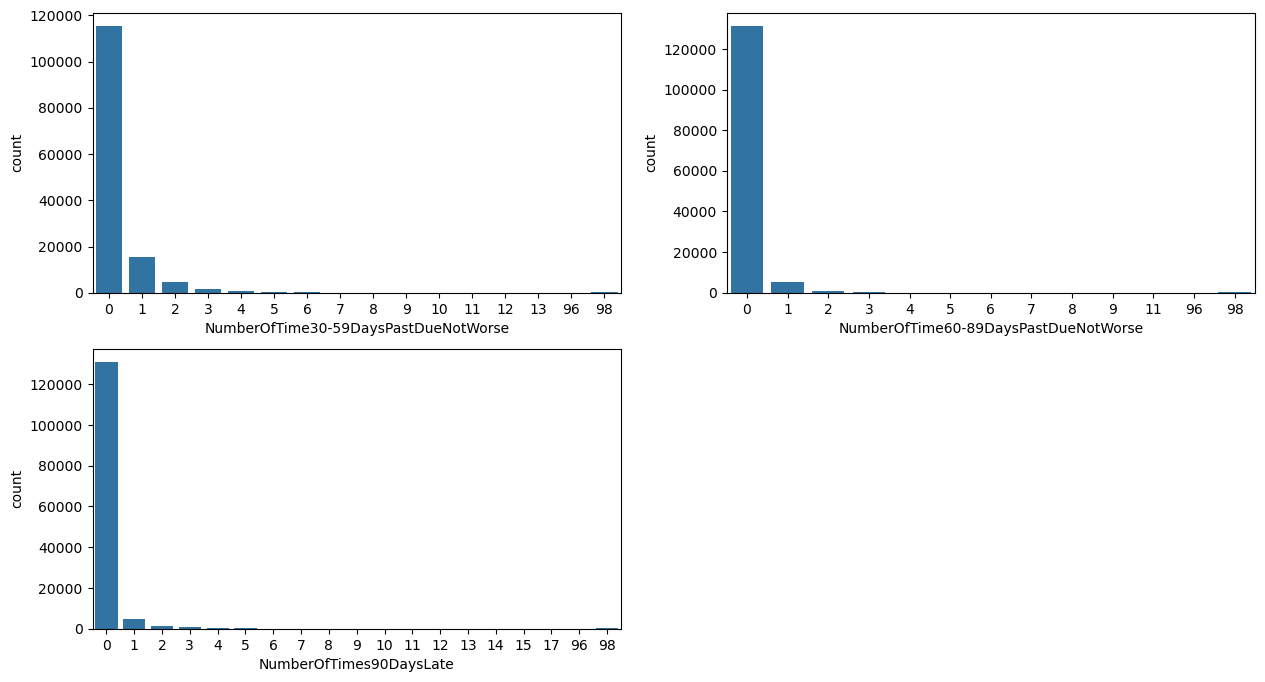

In [36]:
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
sns.countplot(data=data, x='NumberOfTime30-59DaysPastDueNotWorse')

plt.subplot(2,2,2)
sns.countplot(data=data, x='NumberOfTime60-89DaysPastDueNotWorse')

plt.subplot(2,2,3)
sns.countplot(data=data,x='NumberOfTimes90DaysLate')

In [37]:
data[data['NumberOfTime30-59DaysPastDueNotWorse']>96]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
1733,27,1.0,98,98,98,0.000000,0,2700.0,0,0,0.0,1
4705,21,1.0,98,98,98,0.000000,0,2000.0,0,0,0.0,0
5073,33,1.0,98,98,98,0.000000,0,1500.0,0,0,0.0,0
6280,51,1.0,98,98,98,0.000000,0,7500.0,0,0,0.0,1
7032,29,1.0,98,98,98,0.000000,0,1647.0,0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
144230,31,1.0,98,98,98,0.000000,0,2200.0,0,0,3.0,1
144586,60,1.0,98,98,98,0.000000,0,1375.0,0,0,0.0,1
146253,28,1.0,98,98,98,0.000000,0,1664.0,0,0,0.0,1
147128,37,1.0,98,98,98,0.007578,0,3166.0,0,0,0.0,1


In [38]:
data[data['NumberOfTimes90DaysLate']==17]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
103333,62,0.61031,0,0,17,0.23769,0,2700.0,7,0,0.0,1


In [39]:
data = data[data['NumberOfTime30-59DaysPastDueNotWorse'] <= 17]

In [40]:
data.sample()

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
122130,29,0.597405,0,0,0,0.522496,0,5800.0,8,1,2.0,0


<Axes: xlabel='NumberOfOpenCreditLinesAndLoans', ylabel='count'>

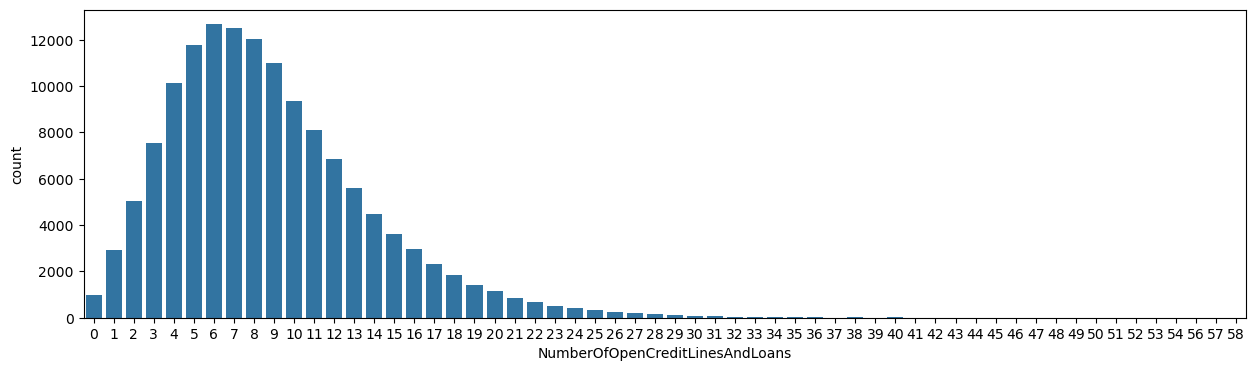

In [41]:
plt.figure(figsize=(15,4))

sns.countplot(x='NumberOfOpenCreditLinesAndLoans',data=data)

In [42]:
data['NumberOfOpenCreditLinesAndLoans'].quantile(0.995)

28.0

In [43]:
data[data['NumberOfOpenCreditLinesAndLoans']>28]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
44,68,0.368876,0,0,0,0.291184,1,1687.5,31,1,0.0,0
373,64,0.082317,0,0,0,0.214426,0,8636.0,29,1,1.0,0
1153,57,0.810546,2,1,0,1.141452,0,3456.0,29,1,1.0,1
1405,64,0.462736,0,0,0,0.575631,0,8600.0,32,3,0.0,0
1617,50,0.267369,0,0,0,0.420292,0,23033.0,46,6,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
147940,66,0.123077,1,0,0,0.432985,0,6214.0,33,1,0.0,0
148091,56,0.306563,1,0,0,0.832949,0,7362.0,43,3,0.0,0
149357,58,0.014284,0,0,0,0.890527,0,4000.0,31,2,0.0,0
149383,63,0.239302,0,0,0,0.291184,1,3153.0,29,1,0.0,0


In [44]:
data[data['NumberOfOpenCreditLinesAndLoans']>28]['age'].mean()

58.40867992766727

**Seeing the data, it points to the fact that credit lines are more for people who are older, which is a valid point. Hence this data is valid**

<Axes: xlabel='NumberRealEstateLoansOrLines', ylabel='count'>

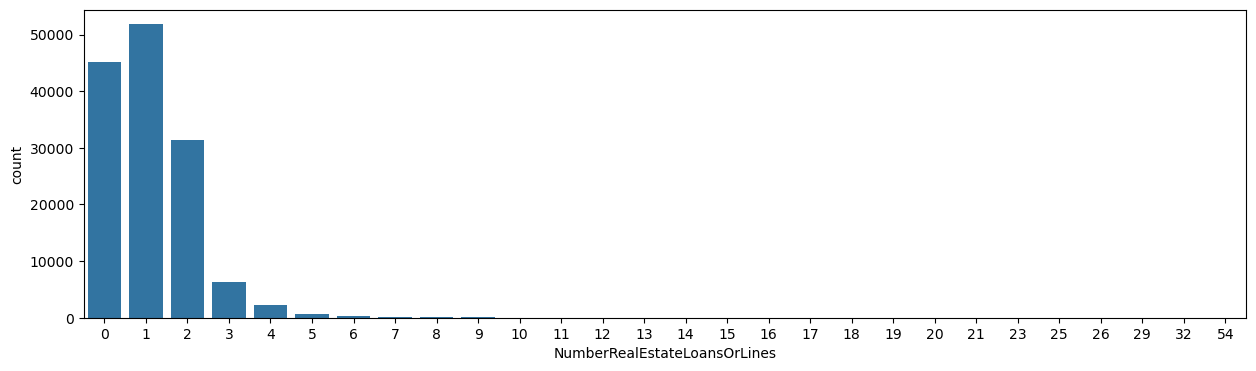

In [45]:
plt.figure(figsize=(15,4))

sns.countplot(x='NumberRealEstateLoansOrLines',data=data)

In [46]:
data[data['NumberRealEstateLoansOrLines']>10]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
2495,48,0.451376,0,0,0,2.511961,0,12080.0,29,17,2.0,1
3256,59,0.062123,0,0,0,0.291184,1,7327.0,18,15,0.0,0
4797,39,0.963012,2,0,0,3.173399,0,5916.0,19,12,2.0,1
4823,65,0.040457,0,0,0,0.986113,0,17570.0,20,11,0.0,0
6978,41,0.167865,0,0,0,0.422033,0,25433.0,14,11,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
139620,67,0.602831,0,0,0,0.291184,1,11515.0,18,11,3.0,0
139704,63,0.269932,1,0,0,1.276536,0,10692.0,27,11,2.0,0
140667,60,0.150342,1,0,0,1.920328,0,4028.0,29,13,3.0,0
141114,47,0.715094,0,0,0,0.671636,0,24883.0,40,20,2.0,0


**The same is observed for NumberRealEstateLoansOrLines column too**

<Axes: xlabel='NumberOfDependents', ylabel='count'>

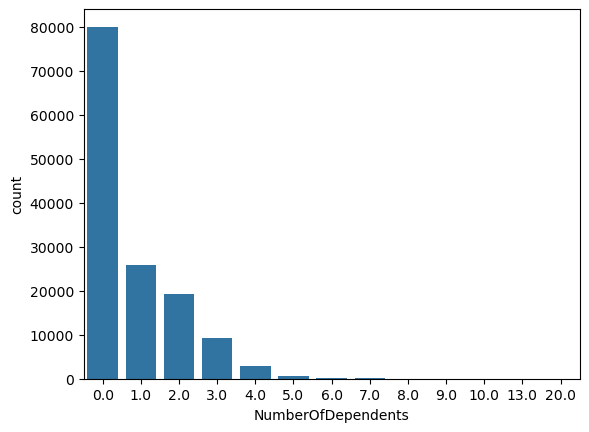

In [47]:
sns.countplot(x='NumberOfDependents',data=data)

In [48]:
data['NumberOfDependents'].quantile(0.9999)

8.0

In [49]:
data[data['NumberOfDependents']>8]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
6299,40,0.226616,1,0,2,0.576539,0,6316.0,11,1,20.0,0
10618,44,0.000000,0,0,0,0.035590,0,12896.0,5,0,10.0,0
12982,39,0.325828,0,0,0,0.027100,0,4833.0,6,0,10.0,0
22698,43,0.139466,1,0,0,0.291184,1,3621.0,9,1,10.0,0
39095,60,0.079194,0,0,0,0.133582,0,7500.0,10,0,10.0,0
42166,58,0.099401,0,0,0,0.291184,1,3592.0,14,1,9.0,0
44848,38,1.000000,0,0,0,0.643728,0,2789.0,5,1,9.0,0
122768,37,0.494849,0,0,1,0.268706,0,3300.0,9,0,9.0,0
123911,47,0.017858,1,0,0,0.368932,0,9166.0,7,1,10.0,0
128034,53,1.000000,1,0,1,0.230054,0,3333.0,3,1,13.0,0


**They dont seem unusual, except the row where dependents=20. But it is only 1 row. Hence, wont affect the model much**

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138265 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   138265 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  138265 non-null  float64
 2   NumberOfTime30-59DaysPastDueNotWorse  138265 non-null  int64  
 3   NumberOfTime60-89DaysPastDueNotWorse  138265 non-null  int64  
 4   NumberOfTimes90DaysLate               138265 non-null  int64  
 5   DebtRatio                             138265 non-null  float64
 6   DebtRatioMissing                      138265 non-null  int32  
 7   MonthlyIncome                         138265 non-null  float64
 8   NumberOfOpenCreditLinesAndLoans       138265 non-null  int64  
 9   NumberRealEstateLoansOrLines          138265 non-null  int64  
 10  NumberOfDependents                    138265 non-null  float64
 11  Serio

In [51]:
data.describe(include='all')

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
count,138265.000000,138265.000000,138265.000000,138265.000000,138265.000000,138265.000000,138265.000000,1.382650e+05,138265.000000,138265.000000,138265.000000,138265.000000
mean,51.814631,0.325232,0.258301,0.066973,0.089907,0.398840,0.148700,6.160335e+03,8.796210,1.099049,0.787170,0.067031
std,14.189202,0.356397,0.716026,0.336090,0.485970,2.547573,0.355794,1.360874e+04,5.114689,1.137137,1.126759,0.250076
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,41.000000,0.033369,0.000000,0.000000,0.000000,0.169629,0.000000,2.871000e+03,5.000000,0.000000,0.000000,0.000000
50%,51.000000,0.166167,0.000000,0.000000,0.000000,0.291184,0.000000,4.915000e+03,8.000000,1.000000,0.000000,0.000000
75%,62.000000,0.557938,0.000000,0.000000,0.000000,0.431269,0.000000,7.744000e+03,11.000000,2.000000,1.000000,0.000000
max,109.000000,4.000000,13.000000,11.000000,17.000000,450.333333,1.000000,3.008750e+06,58.000000,54.000000,20.000000,1.000000


In [52]:
data = data[data['RevolvingUtilizationOfUnsecuredLines']<=1]

In [53]:
data[data['DebtRatio']>400]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
43784,61,1.0,0,0,0,450.333333,0,2.0,7,1,0.0,0


<Axes: xlabel='DebtRatio', ylabel='Density'>

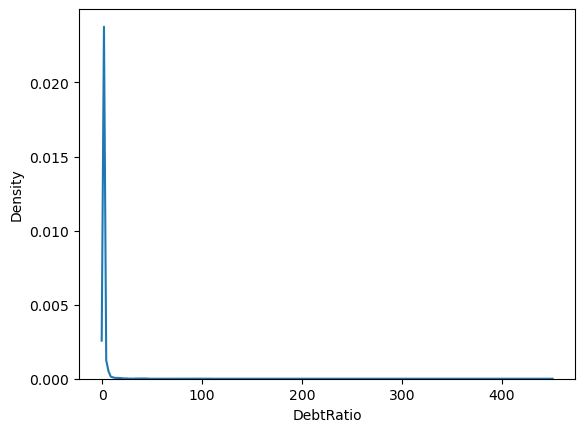

In [54]:
sns.kdeplot(data['DebtRatio'])

In [55]:
print("99.5%: ",data['DebtRatio'].quantile(0.995))
print("99.6%: ",data['DebtRatio'].quantile(0.996))
print("99.7%: ",data['DebtRatio'].quantile(0.997))
print("99.8%: ",data['DebtRatio'].quantile(0.998))
print("99.9%: ",data['DebtRatio'].quantile(0.999))

99.5%:  2.8011230389549784
99.6%:  3.293080872080001
99.7%:  4.020753508892716
99.8%:  5.516567654118019
99.9%:  8.98547538341053


In [56]:
data[(data['DebtRatio']>2)]

,age,RevolvingUtilizationOfUnsecuredLines,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,DebtRatio,DebtRatioMissing,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,SeriousDlqin2yrs
79,41,0.270523,0,0,0,2.797699,0,1042.0,11,2,2.0,0
82,53,0.017259,0,0,0,2.604511,0,12414.0,13,1,2.0,0
165,54,0.637736,2,0,0,3.382196,0,1875.0,9,2,0.0,0
388,60,0.250008,0,0,0,2.086479,0,7550.0,26,0,0.0,0
694,54,0.359412,0,0,0,3.874423,0,1082.0,22,1,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
149683,64,0.049959,0,0,0,4.138699,0,583.0,13,2,0.0,0
149690,59,0.000000,0,0,0,3.067303,0,13000.0,20,4,0.0,0
149749,47,0.579052,0,0,0,8.666667,0,521.0,5,1,0.0,1
149823,59,0.820720,0,0,0,2.094595,0,2515.0,15,3,0.0,0


**Debt ratio cannot be so high. Hence we'll drop these columns**

In [57]:
data = data[(data['DebtRatio']<=2)]

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 134206 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   134206 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  134206 non-null  float64
 2   NumberOfTime30-59DaysPastDueNotWorse  134206 non-null  int64  
 3   NumberOfTime60-89DaysPastDueNotWorse  134206 non-null  int64  
 4   NumberOfTimes90DaysLate               134206 non-null  int64  
 5   DebtRatio                             134206 non-null  float64
 6   DebtRatioMissing                      134206 non-null  int32  
 7   MonthlyIncome                         134206 non-null  float64
 8   NumberOfOpenCreditLinesAndLoans       134206 non-null  int64  
 9   NumberRealEstateLoansOrLines          134206 non-null  int64  
 10  NumberOfDependents                    134206 non-null  float64
 11  Serio

In [59]:
data['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.940263
1    0.059737
Name: proportion, dtype: float64

In [60]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

**The proportion remains almost same. Hence cleaning is completed**

# Saving the dataset as cleaned dataset

In [61]:
data.to_csv('cleaned_data.csv', index=False)